Loading data for XLK...
Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
ARCH-LM Test p-value: 2.1582e-210 (If < 0.05, GARCH is justified)


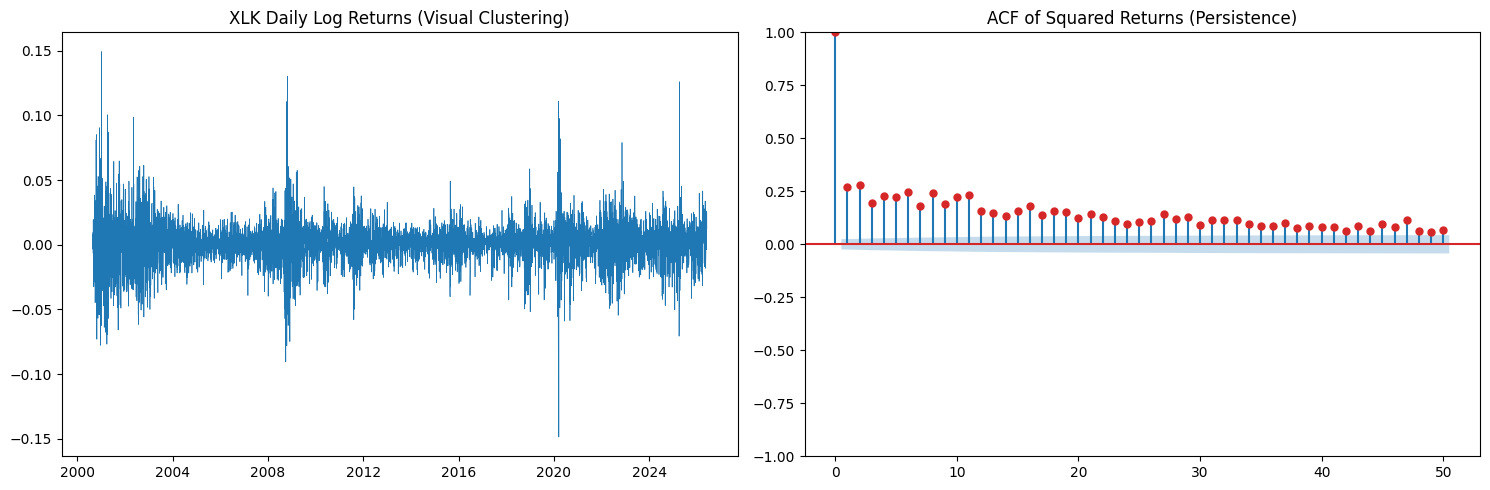

Fitting static models for AIC/BIC comparison...

--- GARCH Model Leaderboard ---


,AIC,BIC
"EGARCH(1,1)",21339.917794,21373.800173
"GJR-GARCH(1,1)",21340.793714,21374.676093
"GARCH(1,1)",21475.482045,21502.587948


In [1]:
# 01_volatility_analysis.ipynb

# 1. Imports and Setup
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch
from IPython.display import display

# Ensure the notebook can find the 'src' package
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, volatility, config

# 2. Ingest Data
print(f"Loading data for {config.TARGET_ETF}...")
raw_df = data_loader.fetch_raw_data(force_refresh=False)
stat_df = features.engineer_stationary_features(raw_df)

# 3. Prove Volatility Clustering (ARCH-LM Test)
returns = stat_df['Log_Return']
returns_mean_adj = returns - returns.mean()
sq_returns = stat_df['Sq_Log_Return']

lm_stat, p_value, f_stat, fp_value = het_arch(returns_mean_adj, nlags=5)
print(f"ARCH-LM Test p-value: {p_value:.4e} (If < 0.05, GARCH is justified)")

# 4. Visualize the Persistence of Volatility
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(returns.index, returns, color='#1f77b4', linewidth=0.5)
axes[0].set_title(f"{config.TARGET_ETF} Daily Log Returns (Visual Clustering)")

plot_acf(sq_returns, lags=50, ax=axes[1], color='#d62728')
axes[1].set_title("ACF of Squared Returns (Persistence)")
plt.tight_layout()
plt.show()

# 5. Model Selection (AIC/BIC Leaderboard)
# We use the static fitting function strictly for this theoretical comparison
leaderboard = volatility.fit_static_models_for_research(returns)
print("\n--- GARCH Model Leaderboard ---")
display(leaderboard)